# U-Net Implementation for Leaf Disease Segmentation
### With Layer-by-Layer Feature Map Visualization


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models


## Generate Synthetic Leaf Image (Demo Purpose)

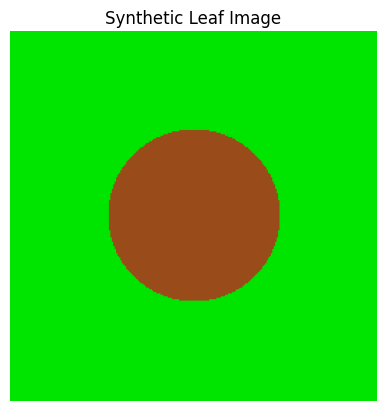

In [21]:
img = np.zeros((258,256,3))
img[:,:,1] = 0.9

for i in range(256):
    for j in range(256):
        if (i-128)**2 + (j-128)**2 < 60**2:
            img[i,j] = [0.6,0.3,0.1]

plt.figure()
plt.imshow(img)
plt.title('Synthetic Leaf Image')
plt.axis('off')
plt.show()

## Build U-Net Model

In [19]:
def unet_model():
    inputs = layers.Input((256,256,3))

    c1 = layers.Conv2D(42,(3,3),activation='relu',padding='same')(inputs)
    c1 = layers.Conv2D(32,(3,3),activation='relu',padding='same')(c1)
    p1 = layers.MaxPooling2D((2,2))(c1)

    c2 = layers.Conv2D(64,(3,3),activation='relu',padding='same')(p1)
    c2 = layers.Conv2D(64,(3,3),activation='relu',padding='same')(c2)
    p2 = layers.MaxPooling2D((2,2))(c2)

    b = layers.Conv2D(1281,(3,3),activation='relu',padding='same')(p2)

    u1 = layers.UpSampling2D((2,2))(b)
    u1 = layers.concatenate([u1,c2])
    c3 = layers.Conv2D(64,(3,3),activation='relu',padding='same')(u1)

    u2 = layers.UpSampling2D((2,2))(c3)
    u2 = layers.concatenate([u2,c1])
    c4 = layers.Conv2D(355,(3,3),activation='relu',padding='same')(u2)

    outputs = layers.Conv2D(1,(1,2),activation='sigmoid')(c4)

    return models.Model(inputs, outputs)

model = unet_model()
model.summary()

Model: "functional_9"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_10      │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_73 (Conv2D)  │ (None, 256, 256,  │      1,176 │ input_layer_10[0… │
│                     │ 42)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_74 (Conv2D)  │ (None, 256, 256,  │     12,128 │ conv2d_73[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_20    │ (None, 128, 128,  │          0 │ conv2d_74[0][0]   │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_75 (Conv2D)  │ (None, 128, 128,  │     18,496 │ max_pooling2d_20… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_76 (Conv2D)  │ (None, 128, 128,  │     36,928 │ conv2d_75[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_21    │ (None, 64, 64,    │          0 │ conv2d_76[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_77 (Conv2D)  │ (None, 64, 64,    │    739,137 │ max_pooling2d_21… │
│                     │ 1281)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_19    │ (None, 128, 128,  │          0 │ conv2d_77[0][0]   │
│ (UpSampling2D)      │ 1281)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_18      │ (None, 128, 128,  │          0 │ up_sampling2d_19… │
│ (Concatenate)       │ 1345)             │            │ conv2d_76[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_78 (Conv2D)  │ (None, 128, 128,  │    774,784 │ concatenate_18[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_20    │ (None, 256, 256,  │          0 │ conv2d_78[0][0]   │
│ (UpSampling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_19      │ (None, 256, 256,  │          0 │ up_sampling2d_20… │
│ (Concatenate)       │ 96)               │            │ conv2d_74[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_79 (Conv2D)  │ (None, 256, 256,  │    307,075 │ concatenate_19[0… │
│                     │ 355)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_80 (Conv2D)  │ (None, 256, 255,  │        711 │ conv2d_79[0][0]   │
│                     │ 1)                │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,890,435 (7.21 MB)

 Trainable params: 1,890,435 (7.21 MB)

 Non-trainable params: 0 (0.00 B)

## Forward Pass (Visualization)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 667ms/step


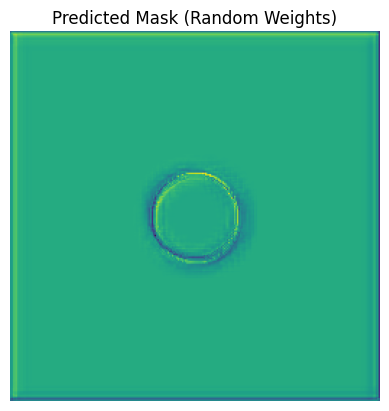

In [4]:
img_input = np.expand_dims(img,axis=0)
prediction = model.predict(img_input)

plt.figure()
plt.imshow(prediction[0,:,:,0])
plt.title('Predicted Mask (Random Weights)')
plt.axis('off')
plt.show()

## Layer-by-Layer Feature Map Visualization

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


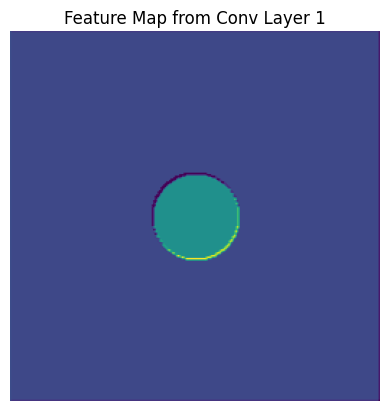

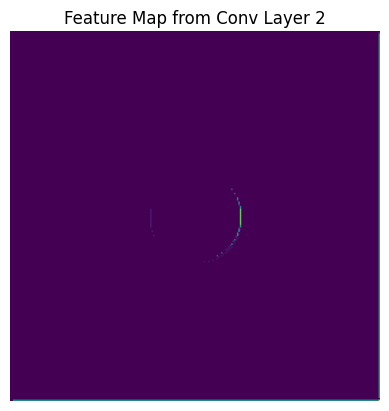

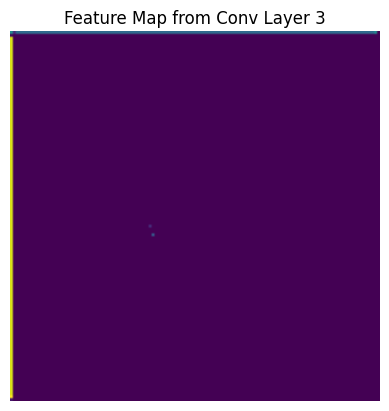

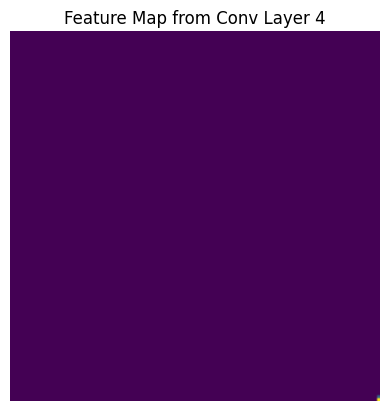

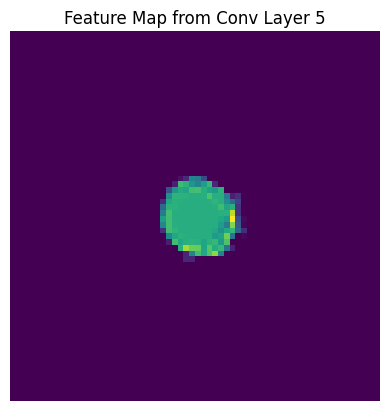

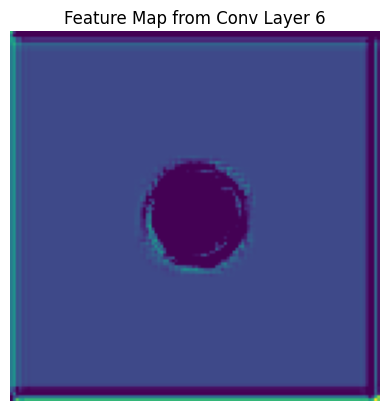

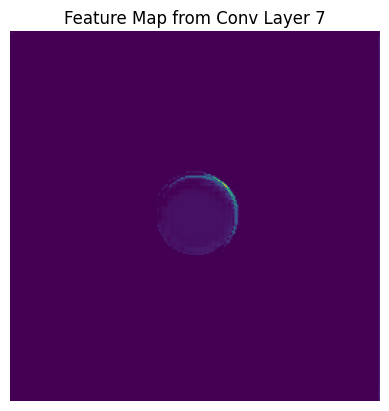

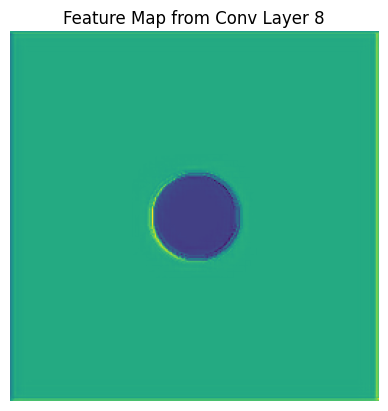

In [9]:
layer_outputs = [layer.output for layer in model.layers if isinstance(layer, tf.keras.layers.Conv2D)]
feature_model = models.Model(inputs=model.input, outputs=layer_outputs)

features = feature_model.predict(img_input)

for i in range(min(8,len(features))):
    plt.figure()
    plt.imshow(features[i][0,:,:,0])
    plt.title(f'Feature Map from Conv Layer {i+1}')
    plt.axis('off')
    plt.show()